In [1]:
import supervision as sv

In [2]:
from PIL import Image

In [3]:
import matplotlib.pyplot as plt

In [4]:
import numpy as np

In [5]:
import json

In [6]:
import cv2

In [7]:
annotations_path = "../data/HRSID_YOLO_png/annotations/train2017.json"

In [8]:
with open(annotations_path, 'r') as f:
    hrsid = json.load(f)

In [67]:
img_idx = 2000

In [68]:
img_id = hrsid["images"][img_idx]["id"]
img_file_name = hrsid["images"][img_idx]["file_name"]
img_annotations = [annotation for annotation in hrsid['annotations'] if annotation['image_id'] == img_id]
img_path = f"../data/HRSID_YOLO_png/images/{img_file_name}"

In [69]:
img = cv2.imread(img_path)

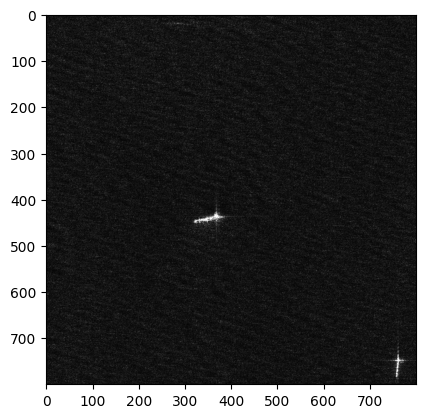

In [70]:
plt.imshow(img)

In [71]:
# get detections from annotations
sv_det = np.expand_dims(np.array(img_annotations[0]["bbox"]), 0)
detections = sv.Detections(xyxy=sv.xywh_to_xyxy(sv_det))

In [72]:
# create annotator
bounding_box_annotator = sv.BoundingBoxAnnotator(color_lookup=sv.ColorLookup.INDEX)

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


In [73]:
# annotate image
annotated_image = bounding_box_annotator.annotate(
    scene=img.copy(), detections=detections)

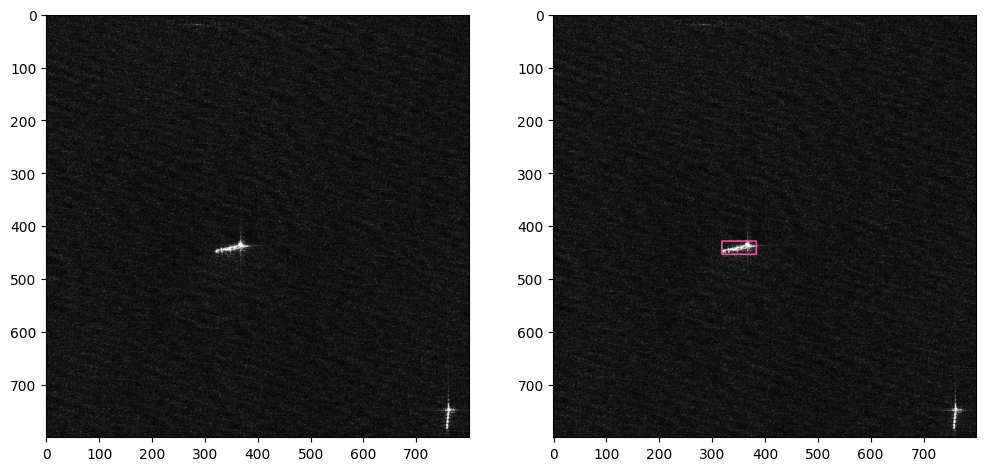

In [74]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img)
axs[1].imshow(annotated_image)
plt.show()